In [ ]:
import numpy as np
import pandas as pd
import io
import os
import time
import tensorflow as tf
from PIL import Image
from glob import glob
import itertools

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, Flatten, BatchNormalization, Dropout, Dense, MaxPool2D, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

# Optional imports for enhanced features
try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
    print("OpenCV not available. Some image processing features will be limited.")

# Configuration
class Config:
    """Configuration settings for the skin cancer classification pipeline"""
    # Image settings
    IMAGE_SIZE = 224  # Standard size for medical images
    BATCH_SIZE = 16   # Reduced batch size for stability
    EPOCHS = 5        # Reduced epochs as requested
    
    # Data paths
    BASE_DIR = r"C:\Users\abdur\vs_code\Sidra-Tasks\sidra thesis\Research Methadology Project-20250403T120511Z-0011\Research Methadology Project\Datasets\HAMM"
    
    # Model settings
    LEARNING_RATE = 0.0001  # Much lower learning rate
    DROPOUT_RATE = 0.5      # Higher dropout to prevent overfitting
    
    # Training settings
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT = 0.2
    PATIENCE = 3            # Reduced patience

config = Config()

def setup_gpu():
    """Configure GPU memory growth if available"""
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
        except RuntimeError as e:
            print(f"GPU configuration error: {e}")
    else:
        print("No GPU found. Using CPU.")

def create_label_mappings():
    """Create label mappings for skin cancer types"""
    lesion_type_dict = {
        'nv': 'Melanocytic nevi (nv)',
        'mel': 'Melanoma (mel)',
        'bkl': 'Benign keratosis-like lesions (bkl)',
        'bcc': 'Basal cell carcinoma (bcc)',
        'akiec': 'Actinic keratoses (akiec)',
        'vasc': 'Vascular lesions (vasc)',
        'df': 'Dermatofibroma (df)'
    }
    
    label_mapping = {
        0: 'nv',
        1: 'mel',
        2: 'bkl',
        3: 'bcc',
        4: 'akiec',
        5: 'vasc',
        6: 'df'
    }
    
    reverse_label_mapping = {value: key for key, value in label_mapping.items()}
    
    return lesion_type_dict, label_mapping, reverse_label_mapping

def load_image_paths(base_dir):
    """Load image paths from the dataset directory"""
    image_folder = os.path.join(base_dir, "skin-cancer-mnist-ham10000")
    
    # Use glob to find all .jpg files in both subfolders
    imageid_path_dict = {
        os.path.splitext(os.path.basename(x))[0]: x
        for x in glob(os.path.join(image_folder, "*", "*.jpg"))
    }
    
    print(f"Total images found: {len(imageid_path_dict)}")
    return imageid_path_dict

def enhanced_load_image_pixels(image_path, target_size=224):
    """Load and preprocess image with proper medical image handling"""
    if not image_path or not os.path.exists(image_path):
        return None
    
    try:
        # Load image
        image = Image.open(image_path)
        
        # Convert to RGB if needed
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        # Resize to target size with high-quality resampling
        image = image.resize((target_size, target_size), Image.LANCZOS)
        
        # Convert to numpy array
        img_array = np.asarray(image)
        
        # Optional: Apply basic preprocessing for medical images
        if CV2_AVAILABLE:
            img_array = enhance_medical_image(img_array)
        
        return img_array
        
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def enhance_medical_image(image):
    """Apply medical-specific image enhancement"""
    if not CV2_AVAILABLE:
        return image
    
    # Convert to LAB color space for better contrast enhancement
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    
    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    
    # Convert back to RGB
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    return enhanced

def load_and_preprocess_data(base_dir):
    """Load and preprocess the HAM10000 dataset"""
    print("Loading HAM10000 dataset...")
    
    # Load image paths
    imageid_path_dict = load_image_paths(base_dir)
    
    # Load metadata
    metadata_path = os.path.join(base_dir, "HAM10000_metadata.csv")
    data = pd.read_csv(metadata_path)
    
    # Handle missing values
    data['age'].fillna(value=int(data['age'].mean()), inplace=True)
    data['age'] = data['age'].astype('int32')
    
    # Create label mappings
    lesion_type_dict, label_mapping, reverse_label_mapping = create_label_mappings()
    
    # Add cell type and path columns
    data['cell_type'] = data['dx'].map(lesion_type_dict.get)
    data['path'] = data['image_id'].map(imageid_path_dict.get)
    
    # Load image pixels with proper size
    print(f"Loading images at {config.IMAGE_SIZE}x{config.IMAGE_SIZE} resolution...")
    data['image_pixel'] = data['path'].apply(
        lambda x: enhanced_load_image_pixels(x, config.IMAGE_SIZE)
    )
    
    # Remove rows with failed image loading
    initial_count = len(data)
    data = data[data['image_pixel'].notnull()]
    final_count = len(data)
    print(f"Successfully loaded {final_count}/{initial_count} images")
    
    # Add numeric labels
    data['label'] = data['dx'].map(reverse_label_mapping.get)
    
    return data, lesion_type_dict, label_mapping, reverse_label_mapping

def analyze_class_distribution(data):
    """Analyze and visualize class distribution"""
    print("\n=== Class Distribution Analysis ===")
    
    class_counts = data['dx'].value_counts()
    print("Original class distribution:")
    for dx, count in class_counts.items():
        print(f"{dx}: {count} images")
    
    # Visualize distribution
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    class_counts.plot(kind='bar')
    plt.title('Original Class Distribution')
    plt.xlabel('Diagnosis')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%')
    plt.title('Class Distribution (Percentage)')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

def create_balanced_dataset_smart(data):
    """Create balanced dataset using smart augmentation"""
    print("\n=== Creating Balanced Dataset ===")
    
    class_counts = data['dx'].value_counts()
    max_count = class_counts.max()
    
    print(f"Target count per class: {max_count}")
    
    balanced_frames = []
    
    for dx in class_counts.index:
        class_data = data[data['dx'] == dx].copy()
        current_count = len(class_data)
        
        if current_count < max_count:
            # Calculate how many more samples we need
            needed = max_count - current_count
            
            # Use smart sampling instead of simple duplication
            additional_samples = create_additional_samples(class_data, needed)
            balanced_frames.append(pd.concat([class_data, additional_samples], ignore_index=True))
            
            print(f"Class {dx}: {current_count} -> {len(balanced_frames[-1])} (+{needed})")
        else:
            balanced_frames.append(class_data)
            print(f"Class {dx}: {current_count} (no augmentation needed)")
    
    # Combine all balanced data
    balanced_data = pd.concat(balanced_frames, ignore_index=True)
    
    print(f"\nFinal balanced dataset: {len(balanced_data)} images")
    
    return balanced_data

def create_additional_samples(class_data, needed_count):
    """Create additional samples using intelligent duplication with variation"""
    additional_samples = []
    
    # Sample with replacement but add some variation
    for i in range(needed_count):
        # Select a random sample from the class
        sample_idx = np.random.randint(0, len(class_data))
        sample = class_data.iloc[sample_idx].copy()
        
        # Add slight variation to avoid exact duplicates
        if sample['image_pixel'] is not None:
            # Apply random augmentation to the image
            augmented_image = apply_random_augmentation(sample['image_pixel'])
            sample['image_pixel'] = augmented_image
        
        additional_samples.append(sample)
    
    return pd.DataFrame(additional_samples)

def apply_random_augmentation(image):
    """Apply random augmentation to an image"""
    if not CV2_AVAILABLE:
        return image
    
    # Random rotation (-10 to 10 degrees)
    angle = np.random.uniform(-10, 10)
    height, width = image.shape[:2]
    center = (width // 2, height // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, rotation_matrix, (width, height))
    
    # Random brightness adjustment
    brightness = np.random.uniform(0.8, 1.2)
    brightened = np.clip(rotated * brightness, 0, 255).astype(np.uint8)
    
    # Random horizontal flip
    if np.random.random() > 0.5:
        brightened = cv2.flip(brightened, 1)
    
    return brightened

def prepare_data_for_training(data):
    """Prepare data for model training - FIXED VERSION"""
    print("\n=== Preparing Data for Training ===")
    
    # Convert image pixels to numpy array
    X = np.stack(data['image_pixel'].values)
    y = np.array(data['label'].values)
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Unique labels: {np.unique(y)}")
    print(f"Label distribution: {np.bincount(y)}")
    
    # Split data with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=config.TEST_SPLIT, random_state=42, stratify=y
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    
    # Normalize data manually
    X_train = X_train.astype(np.float32) / 255.0
    X_test = X_test.astype(np.float32) / 255.0
    
    # Create simple data generators with minimal augmentation
    train_datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        horizontal_flip=True,
        validation_split=config.VALIDATION_SPLIT
    )
    
    # Fit the generator
    train_datagen.fit(X_train)
    
    return X_train, X_test, y_train, y_test, train_datagen



=== Preparing Data for Training (Memory Efficient) ===
Training set: 15590 samples
Test set: 3898 samples

Training Custom CNN
Epoch 1/100
974/974 [==============================] - 138s 142ms/step - loss: 1.4217 - accuracy: 0.4688 - val_loss: 4.1651 - val_accuracy: 0.2967 - lr: 0.0010
Epoch 2/100
974/974 [==============================] - 150s 154ms/step - loss: 1.1366 - accuracy: 0.5631 - val_loss: 2.1413 - val_accuracy: 0.3666 - lr: 0.0010
Epoch 3/100
974/974 [==============================] - 153s 157ms/step - loss: 0.9587 - accuracy: 0.6352 - val_loss: 0.9302 - val_accuracy: 0.6234 - lr: 0.0010
Epoch 4/100
974/974 [==============================] - 152s 156ms/step - loss: 0.8179 - accuracy: 0.6912 - val_loss: 1.0683 - val_accuracy: 0.6179 - lr: 0.0010
Epoch 5/100
974/974 [==============================] - 151s 155ms/step - loss: 0.6681 - accuracy: 0.7437 - val_loss: 0.8598 - val_accuracy: 0.6920 - lr: 0.0010
Epoch 6/100
974/974 [==============================] - 152s 156ms/step -

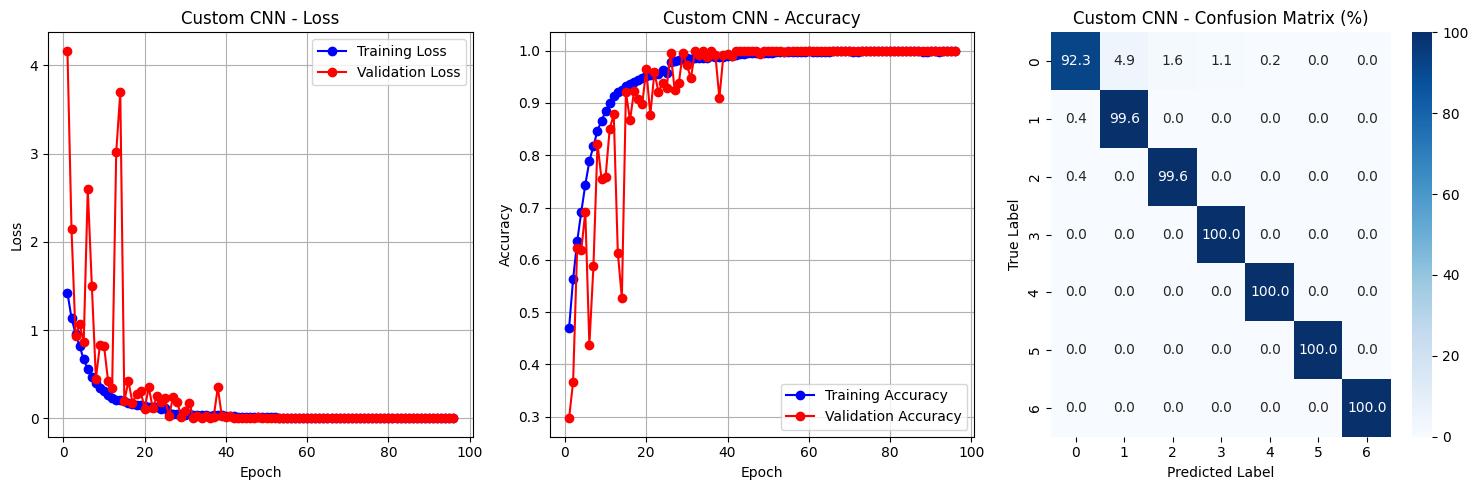


Training ResNet50
Epoch 1/100
974/974 [==============================] - 183s 185ms/step - loss: 1.2375 - accuracy: 0.5494 - val_loss: 1.9752 - val_accuracy: 0.4381 - lr: 0.0010
Epoch 2/100
974/974 [==============================] - 181s 186ms/step - loss: 0.5475 - accuracy: 0.7918 - val_loss: 5.6287 - val_accuracy: 0.2874 - lr: 0.0010
Epoch 3/100
974/974 [==============================] - 181s 186ms/step - loss: 0.3999 - accuracy: 0.8480 - val_loss: 1.7550 - val_accuracy: 0.5171 - lr: 0.0010
Epoch 4/100
974/974 [==============================] - 181s 186ms/step - loss: 0.2964 - accuracy: 0.8878 - val_loss: 0.7049 - val_accuracy: 0.7858 - lr: 0.0010
Epoch 5/100
974/974 [==============================] - 181s 186ms/step - loss: 0.2348 - accuracy: 0.9145 - val_loss: 1.8342 - val_accuracy: 0.5032 - lr: 0.0010
Epoch 6/100
974/974 [==============================] - 181s 186ms/step - loss: 0.2083 - accuracy: 0.9276 - val_loss: 0.2771 - val_accuracy: 0.9059 - lr: 0.0010
Epoch 7/100
974/974 [

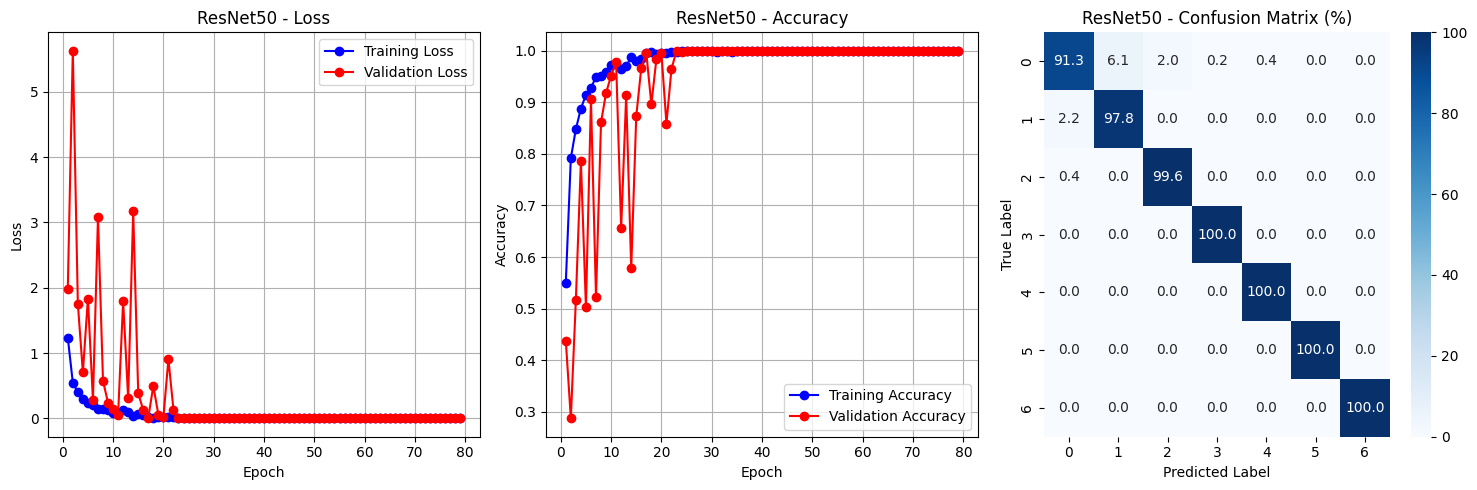


Training ResNet101
Epoch 1/100
974/974 [==============================] - 198s 198ms/step - loss: 1.8097 - accuracy: 0.2932 - val_loss: 1008.7567 - val_accuracy: 0.1427 - lr: 0.0010
Epoch 2/100
974/974 [==============================] - 193s 198ms/step - loss: 1.5273 - accuracy: 0.3747 - val_loss: 1.4249 - val_accuracy: 0.4127 - lr: 0.0010
Epoch 3/100
974/974 [==============================] - 193s 199ms/step - loss: 1.4175 - accuracy: 0.4358 - val_loss: 3.3315 - val_accuracy: 0.4636 - lr: 0.0010
Epoch 4/100
974/974 [==============================] - 194s 199ms/step - loss: 1.0872 - accuracy: 0.5799 - val_loss: 0.7665 - val_accuracy: 0.7188 - lr: 0.0010
Epoch 5/100
974/974 [==============================] - 193s 198ms/step - loss: 0.7486 - accuracy: 0.7219 - val_loss: 0.8064 - val_accuracy: 0.7123 - lr: 0.0010
Epoch 6/100
974/974 [==============================] - 194s 199ms/step - loss: 0.5211 - accuracy: 0.7962 - val_loss: 0.5499 - val_accuracy: 0.7780 - lr: 0.0010
Epoch 7/100
974/9

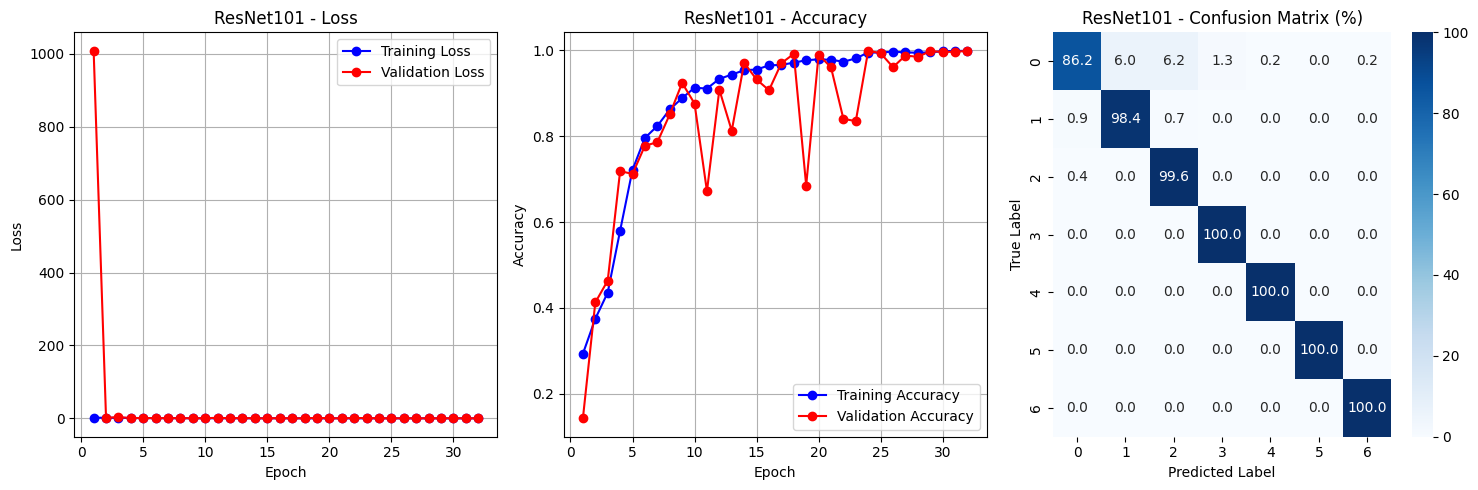


Training EfficientNet-B0
Epoch 1/100
974/974 [==============================] - 193s 193ms/step - loss: 0.6363 - accuracy: 0.7766 - val_loss: 7.0929 - val_accuracy: 0.1550 - lr: 0.0010
Epoch 2/100
974/974 [==============================] - 185s 190ms/step - loss: 0.2812 - accuracy: 0.8980 - val_loss: 5.1216 - val_accuracy: 0.1540 - lr: 0.0010
Epoch 3/100
974/974 [==============================] - 185s 190ms/step - loss: 0.2067 - accuracy: 0.9286 - val_loss: 10.8459 - val_accuracy: 0.1530 - lr: 0.0010
Epoch 4/100
974/974 [==============================] - 185s 190ms/step - loss: 0.1385 - accuracy: 0.9534 - val_loss: 7.4026 - val_accuracy: 0.1695 - lr: 0.0010
Epoch 5/100
974/974 [==============================] - 184s 189ms/step - loss: 0.1308 - accuracy: 0.9586 - val_loss: 9.4198 - val_accuracy: 0.1546 - lr: 0.0010
Epoch 6/100
974/974 [==============================] - 185s 190ms/step - loss: 0.1025 - accuracy: 0.9663 - val_loss: 5.3015 - val_accuracy: 0.1556 - lr: 0.0010
Epoch 7/100
9

c:\Users\abdur\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abdur\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abdur\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


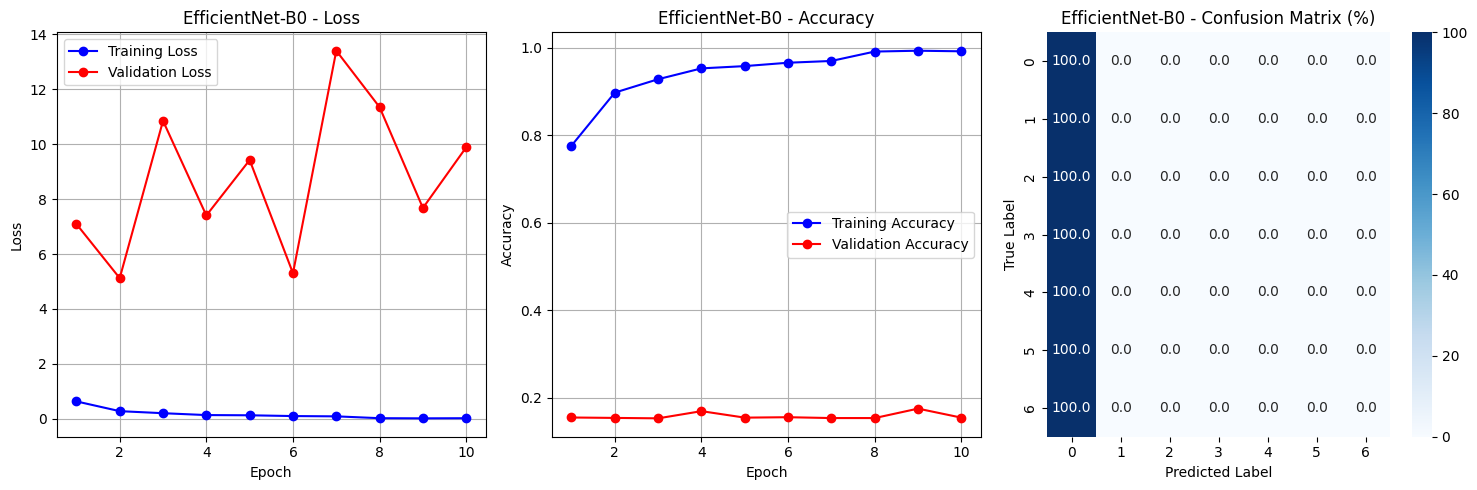


SUMMARY OF ALL MODELS
Custom CNN      | Accuracy: 0.988 | Train Time: 14621.89s | Test Time: 64.92s
ResNet50        | Accuracy: 0.984 | Train Time: 14463.47s | Test Time: 96.32s
ResNet101       | Accuracy: 0.977 | Train Time: 6214.49s | Test Time: 96.78s
EfficientNet-B0 | Accuracy: 0.142 | Train Time: 1856.28s | Test Time: 79.91s


In [29]:
EPOCHS = 100

def create_custom_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3)),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPool2D(2, 2),
        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPool2D(2, 2),
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(7, activation='softmax')
    ])
    return model

def create_resnet50():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3))
    for layer in base_model.layers[-10:]:
        layer.trainable = True
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(7, activation='softmax')
    ])
    return model

def create_resnet101():
    base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3))
    for layer in base_model.layers[-15:]:
        layer.trainable = True
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(7, activation='softmax')
    ])
    return model

def create_efficientnet():
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, 3))
    for layer in base_model.layers[-20:]:
        layer.trainable = True
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(config.DROPOUT_RATE),
        Dense(256, activation='relu'),
        Dropout(config.DROPOUT_RATE),
        Dense(7, activation='softmax')
    ])
    return model

def compile_model(model):
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def prepare_data_for_training(data):
    """Memory-efficient data preparation using generators"""
    print("\n=== Preparing Data for Training (Memory Efficient) ===")
    
    train_data, test_data = train_test_split(
        data, test_size=config.TEST_SPLIT, random_state=42, stratify=data['label']
    )
    
    print(f"Training set: {len(train_data)} samples")
    print(f"Test set: {len(test_data)} samples")
    
    train_datagen = ImageDataGenerator(
        rescale=1.0/255.0,
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        horizontal_flip=True,
        validation_split=config.VALIDATION_SPLIT
    )
    
    test_datagen = ImageDataGenerator(rescale=1.0/255.0)
    
    return train_data, test_data, train_datagen, test_datagen

def create_custom_generator(data, batch_size=16, target_size=(224, 224)):
    """Custom generator that loads images on demand"""
    while True:
        indices = np.random.permutation(len(data))
        for i in range(0, len(data), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_data = data.iloc[batch_indices]
            
            batch_x = []
            batch_y = []
            
            for _, row in batch_data.iterrows():
                img = enhanced_load_image_pixels(row['path'], target_size[0])
                if img is not None:
                    batch_x.append(img)
                    batch_y.append(row['label'])
            
            if len(batch_x) > 0:
                batch_x = np.array(batch_x).astype(np.float32) / 255.0
                batch_y = np.array(batch_y)
                yield batch_x, batch_y

def train_and_evaluate_model(model, model_name, train_data, test_data, train_datagen, test_datagen):
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")
    
    train_steps = len(train_data) // config.BATCH_SIZE
    val_steps = int(train_steps * config.VALIDATION_SPLIT)
    test_steps = len(test_data) // config.BATCH_SIZE
    
    train_generator = create_custom_generator(train_data, config.BATCH_SIZE)
    val_generator = create_custom_generator(train_data.sample(int(len(train_data) * config.VALIDATION_SPLIT)), config.BATCH_SIZE)
    test_generator = create_custom_generator(test_data, config.BATCH_SIZE)
    
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
    
    start_time = time.time()
    history = model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        epochs=EPOCHS,
        validation_data=val_generator,
        validation_steps=val_steps,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    training_time = time.time() - start_time
    
    start_time = time.time()
    test_loss, test_accuracy = model.evaluate(test_generator, steps=test_steps, verbose=0)
    
    y_pred_list = []
    y_true_list = []
    for i, (batch_x, batch_y) in enumerate(test_generator):
        if i >= test_steps:
            break
        batch_pred = model.predict(batch_x, verbose=0)
        y_pred_list.extend(np.argmax(batch_pred, axis=1))
        y_true_list.extend(batch_y)
    
    y_pred = np.array(y_pred_list)
    y_test = np.array(y_true_list)
    testing_time = time.time() - start_time
    
    cm = confusion_matrix(y_test, y_pred)
    cm_percentage = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100
    
    print(f"\nTraining Time: {training_time:.2f} seconds")
    print(f"Testing Time: {testing_time:.2f} seconds")
    print(f"Test Accuracy: {test_accuracy:.3f}")
    
    print(f"\nConfusion Matrix (Percentage) for {model_name}:")
    print(cm_percentage)
    
    report = classification_report(y_test, y_pred, digits=3)
    print(f"\nClassification Report for {model_name}:")
    print(report)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    epochs_range = range(1, len(history.history['loss']) + 1)
    plt.plot(epochs_range, history.history['loss'], 'bo-', label='Training Loss')
    plt.plot(epochs_range, history.history['val_loss'], 'ro-', label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history.history['accuracy'], 'bo-', label='Training Accuracy')
    plt.plot(epochs_range, history.history['val_accuracy'], 'ro-', label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 3)
    sns.heatmap(cm_percentage, annot=True, fmt='.1f', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix (%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()
    
    del model
    tf.keras.backend.clear_session()
    import gc
    gc.collect()
    
    return history, training_time, testing_time, test_accuracy

train_data, test_data, train_datagen, test_datagen = prepare_data_for_training(balanced_data)

models_config = [
    (create_custom_cnn, "Custom CNN"),
    (create_resnet50, "ResNet50"),
    (create_resnet101, "ResNet101"),
    (create_efficientnet, "EfficientNet-B0")
]

results = {}

for model_func, model_name in models_config:
    model = compile_model(model_func())
    history, train_time, test_time, test_acc = train_and_evaluate_model(
        model, model_name, train_data, test_data, train_datagen, test_datagen
    )
    results[model_name] = {
        'history': history,
        'train_time': train_time,
        'test_time': test_time,
        'test_accuracy': test_acc
    }

print(f"\n{'='*60}")
print("SUMMARY OF ALL MODELS")
print(f"{'='*60}")
for name, result in results.items():
    print(f"{name:15} | Accuracy: {result['test_accuracy']:.3f} | Train Time: {result['train_time']:.2f}s | Test Time: {result['test_time']:.2f}s")